In [57]:
import numpy as np
np.random.seed(0)

X_train_fpath = './data/data/X_train'
Y_train_fpath = './data/data/Y_train'

# 把csv文件转换成numpy的数组
with open(X_train_fpath) as f:
    next(f)
    X_train = np.array([line.strip('\n').split(',')[1:] for line in f], dtype = float)
with open(Y_train_fpath) as f:
    next(f)
    Y_train = np.array([line.strip('\n').split(',')[1] for line in f], dtype = float)


In [59]:
def _normalize(X, train = True, specified_column = None, X_mean = None, X_std = None):
    # This function normalizes specific columns of X.
    # The mean and standard variance of training data will be reused when processing testing data.
    #
    # Arguments:
    #     X: data to be processed
    #     train: 'True' when processing training data, 'False' for testing data
    #     specific_column: indexes of the columns that will be normalized. If 'None', all columns
    #         will be normalized.
    #     X_mean: mean value of training data, used when train = 'False'
    #     X_std: standard deviation of training data, used when train = 'False'
    # Outputs:
    #     X: normalized data
    #     X_mean: computed mean value of training data
    #     X_std: computed standard deviation of training data

    if specified_column == None:
        specified_column = np.arange(X.shape[1])
        # print(specified_column)
        # 输出列的ID：
        #[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
        #  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
        # ...
        # 504 505 506 507 508 509]
    if train:
        X_mean = np.mean(X[:, specified_column] ,0).reshape(1, -1)
        X_std  = np.std(X[:, specified_column], 0).reshape(1, -1)

    X[:,specified_column] = (X[:, specified_column] - X_mean) / (X_std + 1e-8) #1e-8防止除零
     
    return X, X_mean, X_std








In [60]:
def _train_test_split(X, Y, test_ratio = 0.25):
    # This function spilts data into training set and testing set.
    train_size = int(len(X) * (1 - test_ratio))
    return X[:train_size], Y[:train_size], X[train_size:], Y[train_size:]
 
# Normalize training and testing data
X_train, X_mean, X_std = _normalize(X_train, train = True)


# 把数据分成训练集和测试集
test_ratio = 0.1
X_train, Y_train, X_test, Y_test = _train_test_split(X_train, Y_train, test_ratio = test_ratio)

train_size = X_train.shape[0]
test_size = X_test.shape[0]
data_dim = X_train.shape[1]
print('Size of training set: {}'.format(train_size))
print('Size of testing set: {}'.format(test_size))
print('Dimension of data: {}'.format(data_dim))

Size of training set: 48830
Size of testing set: 5426
Dimension of data: 510


In [62]:
def _shuffle(X, Y):
    # This function shuffles two equal-length list/array, X and Y, together.
    randomize = np.arange(len(X))
    np.random.shuffle(randomize)
    return (X[randomize], Y[randomize])

def _sigmoid(z):
    # Sigmoid function can be used to calculate probability.
    # To avoid overflow, minimum/maximum output value is set.
    return np.clip(1 / (1.0 + np.exp(-z)), 1e-8, 1 - (1e-8))

def _f(X, w, b):
    # This is the logistic regression function, parameterized by w and b
    #
    # Arguements:
    #     X: input data, shape = [batch_size, data_dimension]
    #     w: weight vector, shape = [data_dimension, ]
    #     b: bias, scalar
    # Output:
    #     predicted probability of each row of X being positively labeled, shape = [batch_size, ]
    return _sigmoid(np.matmul(X, w) + b)

def _predict(X, w, b):
    # This function returns a truth value prediction for each row of X 
    # by rounding the result of logistic regression function.
    return np.round(_f(X, w, b)).astype(np.int)
    
def _accuracy(Y_pred, Y_label):
    # This function calculates prediction accuracy
    acc = 1 - np.mean(np.abs(Y_pred - Y_label))
    return acc

In [63]:
def _cross_entropy_loss(y_pred, Y_label):
    # This function computes the cross entropy.
    #
    # Arguements:
    #     y_pred: probabilistic predictions, float vector
    #     Y_label: ground truth labels, bool vector
    # Output:
    #     cross entropy, scalar
    cross_entropy = -np.dot(Y_label, np.log(y_pred)) - np.dot((1 - Y_label), np.log(1 - y_pred))
    return cross_entropy

In [64]:
def _gradient(X, Y_label, w, b):
    # This function computes the gradient of cross entropy loss with respect to weight w and bias b.
    y_pred = _f(X, w, b)
    pred_error = Y_label - y_pred
    w_grad = -np.sum(pred_error * X.T, 1)
    b_grad = -np.sum(pred_error)
    return w_grad, b_grad

In [ ]:
# 初始化权重w和b，令它们都为0
w = np.zeros((data_dim,))	#[0,0,0,...,0] 510
b = np.zeros((1,))		 	#[0]

# 训练时的超参数
max_iter = 10
batch_size = 8
learning_rate = 0.2

# 保存每个iteration的loss和accuracy，以便后续画图
train_loss = []
dev_loss = []
train_acc = []
dev_acc = []

# 累计参数更新的次数
step = 1

# 迭代训练
for epoch in range(max_iter):
    # 在每个epoch开始时，随机打散训练数据
    X_train, Y_train = _shuffle(X_train, Y_train)
        
    # Mini-batch训练
    for idx in range(int(np.floor(train_size / batch_size))):
        X = X_train[idx*batch_size:(idx+1)*batch_size]
        Y = Y_train[idx*batch_size:(idx+1)*batch_size]

        # 计算梯度
        w_grad, b_grad = _gradient(X, Y, w, b)
            
        # 梯度下降法更新
        # 学习率随时间衰减
        w = w - learning_rate/np.sqrt(step) * w_grad
        b = b - learning_rate/np.sqrt(step) * b_grad

        step = step + 1
            
    # 计算训练集的loss和accuracy
    y_train_pred = _f(X_train, w, b)
    Y_train_pred = np.round(y_train_pred)
    train_acc.append(_accuracy(Y_train_pred, Y_train))
    train_loss.append(_cross_entropy_loss(y_train_pred, Y_train) / train_size)


print('Training loss: {}'.format(train_loss[-1]))
print('Training accuracy: {}'.format(train_acc[-1]))

Training loss: 0.2713554352464066
Training accuracy: 0.8836166291214418


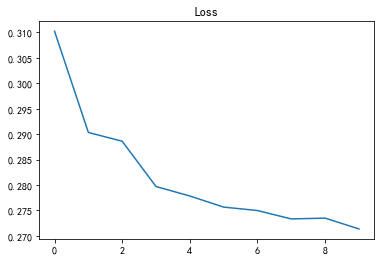

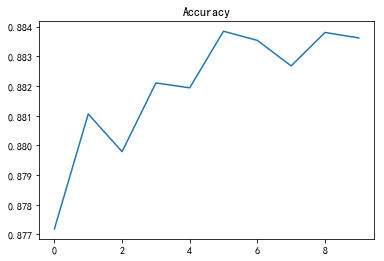

In [51]:
import matplotlib.pyplot as plt

# Loss曲线
plt.plot(train_loss)
plt.title('Loss')
plt.savefig('loss.png')
plt.show()

# Accuracy曲线
plt.plot(train_acc)
plt.title('Accuracy')
plt.savefig('acc.png')
plt.show()

In [53]:
def __predict_threshold(X, w, b, threshold):
    # This function returns a truth value prediction for each row of X
    # 计算线性模型的预测值
    linear_pred = np.dot(X, w) + b
    sigmoid_pred = 1 / (1 + np.exp(-linear_pred))  # 使用sigmoid转换为概率
    
    # 根据阈值进行二分类
    y_pred = (sigmoid_pred >= threshold).astype(int)
    
    return y_pred

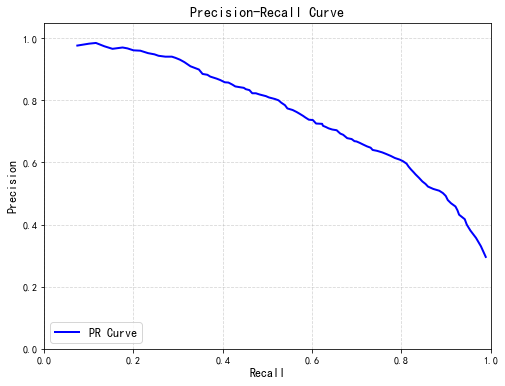

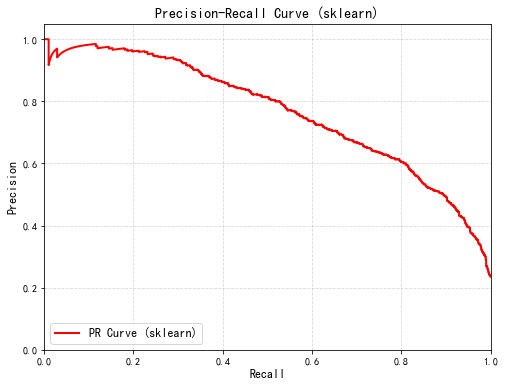

In [71]:
def _predict_threshold(X, w, b, threshold=0.5):
    """
    根据给定阈值进行预测
    参数:
        X: 输入特征矩阵
        w: 权重向量
        b: 偏置项
        threshold: 阈值(0到1之间)
    返回:
        预测结果(0或1)
    """
    # 使用已定义的_f函数计算概率
    prob = _f(X, w, b)
    # 根据阈值判断类别
    return (prob >= threshold).astype(np.int)
from sklearn.metrics import precision_score, recall_score
import warnings

def _get_prediction_recall(X_test, Y_test, w, b, thresholds):
    """
    计算不同阈值下的精确率和召回率
    参数:
        X_test: 测试集特征
        Y_test: 测试集标签
        w: 权重向量
        b: 偏置项
        thresholds: 阈值列表
    返回:
        precisions: 各阈值对应的精确率列表
        recalls: 各阈值对应的召回率列表
    """
    precisions = []
    recalls = []
    
    # 预先计算所有样本的概率值(提高效率)
    y_scores = _f(X_test, w, b)
    
    for threshold in thresholds:
        y_pred = _predict_threshold(X_test, w, b, threshold)
        
        # 处理可能的除零情况
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                # 尝试使用新版本接口
                precision = precision_score(Y_test, y_pred, zero_division=0)
                recall = recall_score(Y_test, y_pred, zero_division=0)
            except TypeError:
                # 回退到旧版本处理方式
                try:
                    precision = precision_score(Y_test, y_pred)
                    recall = recall_score(Y_test, y_pred)
                except:
                    precision = 0.0
                    recall = 0.0
        
        precisions.append(precision)
        recalls.append(recall)
    
    return precisions, recalls
# 生成阈值列表
thresholds = np.arange(0.01, 1, 0.01)

# 计算精确率和召回率
precisions, recalls = _get_prediction_recall(X_test, Y_test, w, b, thresholds)

# 绘制PR曲线
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, 'b-', linewidth=2, label='PR Curve')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)  # 注意True首字母大写
plt.legend(loc='lower left', fontsize=12)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()
from sklearn.metrics import precision_recall_curve

# 计算更平滑的PR曲线
y_scores = _f(X_test, w, b)
precision, recall, _ = precision_recall_curve(Y_test, y_scores)

# 绘制更平滑的PR曲线
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, 'r-', linewidth=2, label='PR Curve (sklearn)')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve (sklearn)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left', fontsize=12)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()